In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [114]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [115]:
import load_data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from IPython.display import display, Markdown, Math
import numpy as np
from scipy.stats import norm
import src.analysis_utils as analysis_utils

In [87]:
df_funnel = load_data.load("funnel")

funnel table loaded!


## Hypthesis test 

In [84]:
test_completed = df_funnel[(df_funnel.variation == "Test") & (df_funnel['start'] == 1)].confirm.sum()
test_total = df_funnel[df_funnel.variation == "Test"].start.sum()

control_completed = df_funnel[(df_funnel.variation == "Control") & (df_funnel['start'] == 1)].confirm.sum()
control_total = df_funnel[df_funnel.variation == "Control"].start.sum()

#test_completion_rate = test_completed / test_total
#control_completion_rate = control_completed / control_total


p_c = control_completed / control_total
p_t = test_completed / test_total
diff = p_t - p_c

se = np.sqrt(
    p_t * (1 - p_t) / test_total
    +
    p_c * (1 - p_c) / control_total
)

z = diff / se

p_value = norm.sf(z)

ci_lower = diff - 1.96 * se
ci_upper = diff + 1.96 * se
#ci = f"({ci_lower:.2%}, {ci_upper:.2%})"

absolute_lift = p_t - p_c
relative_lift = (p_t - p_c)/p_c

In [86]:
display(
    Markdown(
        f"""
# Completion Rate Analysis

Would these changes encourage more clients to complete the process?

### Hypothesis

$$
H_0: p_t = p_c
$$

$$
H_1: p_t > p_c
$$

### Two-Proportion Z-Test

$$
Z=
\\frac{{
\\hat p_t-\\hat p_c
}}
{{
\\sqrt{{
\\frac{{\\hat p_t(1-\\hat p_t)}}{{n_t}}
+
\\frac{{\\hat p_c(1-\\hat p_c)}}{{n_c}}
}}
}}
$$

### 95% Confidence Interval

$$
(\\hat p_t-\\hat p_c)
\\pm
1.96
\\times
\\sqrt{{
\\frac{{\\hat p_t(1-\\hat p_t)}}{{n_t}}
+
\\frac{{\\hat p_c(1-\\hat p_c)}}{{n_c}}
}}
$$

### Results

| Metric | Value |
|----------|----------:|
| Control Completion Rate | {p_c:.2%} |
| Test Completion Rate | {p_t:.2%} |
| Absolute Lift | {absolute_lift:.2%} |
| 95% CI for Lift | [{ci_lower:.2%}, {ci_upper:.2%}] |
| Z-statistic | {z:.4f} |
| P-value | {p_value:.4e} |

### Conclusion

The redesigned digital interface significantly improved the completion rate compared with the control experience. The completion rate increased from {p_c:.2%} to {p_t:.2%}, representing an absolute lift of {absolute_lift:.2%}.

A two-proportion Z-test indicates that the improvement is statistically significant (Z = {z:.4f}, p < 0.001). Therefore, we reject the null hypothesis and conclude that the new interface leads to a higher completion rate.

However, the 95% confidence interval for the lift is [{ci_lower:.2%}, {ci_upper:.2%}], which lies entirely below the predefined 5% business target. While the redesign delivers a meaningful and statistically significant improvement, the experiment does not provide sufficient evidence that the true improvement reaches or exceeds 5%.
"""
    )
)


# Completion Rate Analysis

Would these changes encourage more clients to complete the process?

### Hypothesis

$$
H_0: p_t = p_c
$$

$$
H_1: p_t > p_c
$$

### Two-Proportion Z-Test

$$
Z=
\frac{
\hat p_t-\hat p_c
}
{
\sqrt{
\frac{\hat p_t(1-\hat p_t)}{n_t}
+
\frac{\hat p_c(1-\hat p_c)}{n_c}
}
}
$$

### 95% Confidence Interval

$$
(\hat p_t-\hat p_c)
\pm
1.96
\times
\sqrt{
\frac{\hat p_t(1-\hat p_t)}{n_t}
+
\frac{\hat p_c(1-\hat p_c)}{n_c}
}
$$

### Results

| Metric | Value |
|----------|----------:|
| Control Completion Rate | 65.47% |
| Test Completion Rate | 69.01% |
| Absolute Lift | 3.54% |
| 95% CI for Lift | [2.72%, 4.37%] |
| Z-statistic | 8.4270 |
| P-value | 1.7730e-17 |

### Conclusion

The redesigned digital interface significantly improved the completion rate compared with the control experience. The completion rate increased from 65.47% to 69.01%, representing an absolute lift of 3.54%.

A two-proportion Z-test indicates that the improvement is statistically significant (Z = 8.4270, p < 0.001). Therefore, we reject the null hypothesis and conclude that the new interface leads to a higher completion rate.

However, the 95% confidence interval for the lift is [2.72%, 4.37%], which lies entirely below the predefined 5% business target. While the redesign delivers a meaningful and statistically significant improvement, the experiment does not provide sufficient evidence that the true improvement reaches or exceeds 5%.


In [89]:
steps = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

funnel_summary = (
    df_funnel
    .groupby('variation')[steps]
    .sum()
)

funnel_summary

,start,step_1,step_2,step_3,confirm
variation,,,,,
Control,23397,20152,18650,17422,15434
Test,26679,24267,22258,20881,18687


In [90]:
funnel_pct = funnel_summary.div(
    funnel_summary['start'],
    axis=0
) * 100

funnel_pct

,start,step_1,step_2,step_3,confirm
variation,,,,,
Control,100.0,86.130701,79.711074,74.462538,65.965722
Test,100.0,90.959181,83.428914,78.267551,70.043855


In [91]:
dropoff = funnel_pct.diff(axis=1) * -1

dropoff

,start,step_1,step_2,step_3,confirm
variation,,,,,
Control,NaN,13.869299,6.419626,5.248536,8.496816
Test,NaN,9.040819,7.530267,5.161363,8.223697


In [94]:
import plotly.graph_objects as go

steps = ['start','step_1','step_2','step_3','confirm']

control = funnel_summary.loc['Control']
test = funnel_summary.loc['Test']

fig = go.Figure()

fig.add_trace(
    go.Funnel(
        name='Control',
        y=steps,
        x=control
    )
)

fig.add_trace(
    go.Funnel(
        name='Test',
        y=steps,
        x=test
    )
)

fig.show()

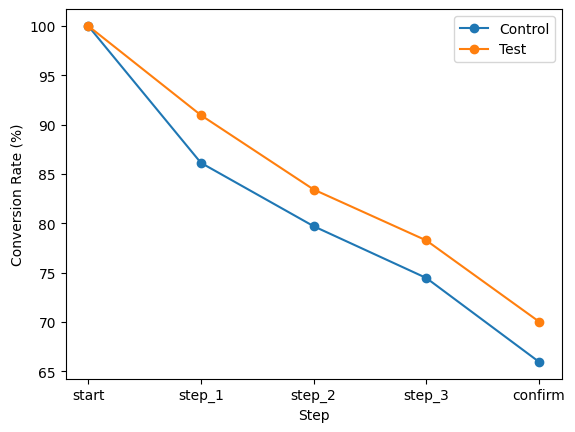

In [92]:
for group in funnel_pct.index:
    plt.plot(
        steps,
        funnel_pct.loc[group],
        marker='o',
        label=group
    )

plt.ylabel("Conversion Rate (%)")
plt.xlabel("Step")
plt.legend()
plt.show()

In [112]:
df_client = load_data.load("client_profile")
df_client.head()

client_profile table loaded!


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation
0,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control
1,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control
2,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Test
3,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Test
4,4876926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Test


In [98]:
df_client.isna().mean().sort_values(ascending=False)

clnt_age            0.000212
clnt_tenure_yr      0.000198
clnt_tenure_mnth    0.000198
gendr               0.000198
num_accts           0.000198
bal                 0.000198
calls_6_mnth        0.000198
logons_6_mnth       0.000198
client_id           0.000000
variation           0.000000
dtype: float64

In [116]:
df_seg = (
    df_funnel
    .merge(
        df_client,
        on=['client_id', 'variation'],
        how='left'
    )
    .dropna()
)

"""
df_seg['age_group'] = pd.cut(
    df_seg['clnt_age'],
    bins=[0,40,60,120],
    labels=['<40','40-60','60+']
)
"""

df_seg = analysis_utils.add_segment(
    df_seg,
    column="clnt_age",
    bins=[0,40,60,float("inf")],
    labels=["<40","40-60","60+"],
    segment_name="age_group"
)

In [117]:
age_completion = (
    df_seg
    .groupby(['variation','age_group'])['confirm']
    .mean()
    .reset_index()
)
age_completion

/var/folders/hv/krhwb7sd6nzbsxrj3wcwcg480000gn/T/ipykernel_46020/4166756497.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['variation','age_group'])['confirm']


,variation,age_group,confirm
0,Control,<40,0.674291
1,Control,40-60,0.672515
2,Control,60+,0.603770
3,Test,<40,0.721202
4,Test,40-60,0.692212
5,Test,60+,0.651957


In [118]:
steps = [
    'start',
    'step_1',
    'step_2',
    'step_3',
    'confirm'
]

age_funnel = (
    df_seg
    .groupby(['age_group', 'variation'])[steps]
    .sum()
)

age_funnel

/var/folders/hv/krhwb7sd6nzbsxrj3wcwcg480000gn/T/ipykernel_46020/3505874105.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['age_group', 'variation'])[steps]


start  step_1  step_2  step_3  confirm
age_group variation                                        
<40       Control     8304    7185    6784    6220     5631
          Test        9792    8838    8165    7612     7106
40-60     Control     9194    7899    7421    6936     6210
          Test       10409    9470    8767    8150     7262
60+       Control     5893    5062    4439    4260     3587
          Test        6471    5952    5320    5114     4314

In [120]:
age_funnel_pct = (
    age_funnel
    .div(age_funnel['start'], axis=0)
    * 100
)

age_funnel_pct

start     step_1     step_2     step_3    confirm
age_group variation                                                   
<40       Control    100.0  86.524566  81.695568  74.903661  67.810694
          Test       100.0  90.257353  83.384395  77.736928  72.569444
40-60     Control    100.0  85.914727  80.715684  75.440505  67.544050
          Test       100.0  90.978961  84.225190  78.297627  69.766548
60+       Control    100.0  85.898524  75.326659  72.289157  60.868827
          Test       100.0  91.979601  82.212950  79.029516  66.666667

In [122]:
age_completion = (
    age_funnel_pct['confirm']
    .unstack()
)

age_completion['lift'] = (
    age_completion['Test']
    - age_completion['Control']
)

age_completion

variation,Control,Test,lift
age_group,,,
<40,67.810694,72.569444,4.758751
40-60,67.544050,69.766548,2.222498
60+,60.868827,66.666667,5.797839


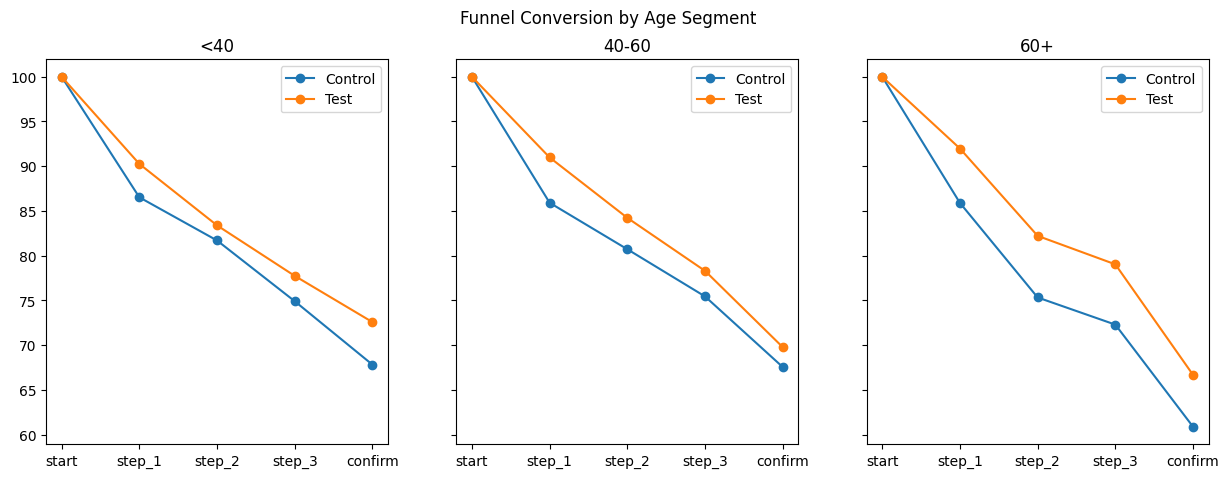

In [123]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5),
    sharey=True
)

steps = ['start','step_1','step_2','step_3','confirm']

for ax, age_group in zip(
    axes,
    age_funnel_pct.index.get_level_values(0).unique()
):

    temp = age_funnel_pct.loc[age_group]

    for variation in temp.index:

        ax.plot(
            steps,
            temp.loc[variation, steps],
            marker='o',
            label=variation
        )

    ax.set_title(age_group)
    ax.legend()

plt.suptitle('Funnel Conversion by Age Segment')
plt.show()

<Axes: xlabel='age_group'>

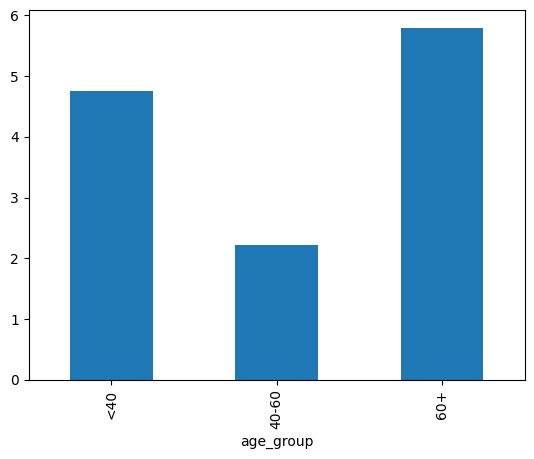

In [124]:
lift = (
    age_funnel_pct['confirm']
    .unstack()
)

lift['lift'] = (
    lift['Test']
    - lift['Control']
)

lift['lift'].plot.bar()